In [1]:
import sys,os
notebook_dir = os.getcwd()  # Gets current working directory
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)
sys.path.append(parent_dir + "/python_code")

In [2]:
from implementation.Cloth import Cloth
from implementation.utils import createRectangularMesh
import numpy as np
np.set_printoptions(threshold=sys.maxsize)
import time

In [3]:
# Caida libre
na = 2; nb = 3
# na = 4; nb = 7
np.random.seed(1)
X, T = createRectangularMesh(a = 0.5, b = 0.8, na = na, nb = nb, h = 0.2)
X[:,2] += 0.7; 
X += 0.0001*np.random.randn(X.shape[0],3) 

In [4]:
cloth = Cloth(X, T); 
dt = cloth.estimateTimeStep(L=0.8)

Based on your mesh, your best dt is: 0.037484102421494095


In [5]:
# solver parameters
dt = 0.002 #time step
tol = 0.0095 # up to 0.75% of relative error in constraint satisfaction to stop iterations

#physical parameters
rho = 0.1 #cloth density
delta = 0.08 # aerodynamics parameter: between 0 and rho
kappa = 0.2*1e-4 # stifness or bending resistance
alpha = 0.2 #damping of oscillations
shr = 1.2*1e-4 #allowed shearing resistance
str = 0.005*1e-4 #allowed stretching resistance
mu_f = 0.45 #friction with the floor
mu_s = 0.35 #friction with the cloth itself
thck = 0.95 #size of the balls

cloth.setSimulatorParameters(dt=dt,tol=tol,
                                rho=rho,delta=delta,kappa=kappa,shr=shr,
                                str=str,alpha=alpha,mu_f=mu_f,mu_s=mu_s,
                                thck=thck)

In [6]:
tf = int(6/dt)
tf = 1000; t = np.linspace(0,2*np.pi,tf); freq = 3
inds_ctr = [0, na-1]
u = X[inds_ctr]

In [7]:
print(cloth.A2)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 6)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (1, 2)	1
  (1, 3)	1
  (1, 4)	1
  (1, 5)	1


In [8]:
Xc = cloth.positions
Xc

array([[-2.49837565e-01, -4.00061176e-01,  8.87447183e-01],
       [ 2.49892703e-01, -3.99913459e-01,  8.87269846e-01],
       [-2.49825519e-01, -7.61206901e-05,  8.87531904e-01],
       [ 2.49975063e-01,  1.46210794e-04,  8.87293986e-01],
       [-2.50032242e-01,  3.99961595e-01,  8.87613377e-01],
       [ 2.49890011e-01,  3.99982757e-01,  8.87412214e-01]])

In [38]:
F = cloth.faces    
print(f'faces: {F}')
Xf = Xc[F]
Xf

faces: [[0 1 3 2]
 [2 3 5 4]]


array([[[-2.49837565e-01, -4.00061176e-01,  8.87447183e-01],
        [ 2.49892703e-01, -3.99913459e-01,  8.87269846e-01],
        [ 2.49975063e-01,  1.46210794e-04,  8.87293986e-01],
        [-2.49825519e-01, -7.61206901e-05,  8.87531904e-01]],

       [[-2.49825519e-01, -7.61206901e-05,  8.87531904e-01],
        [ 2.49975063e-01,  1.46210794e-04,  8.87293986e-01],
        [ 2.49890011e-01,  3.99982757e-01,  8.87412214e-01],
        [-2.50032242e-01,  3.99961595e-01,  8.87613377e-01]]])

In [39]:
Xw_face_centers = 0.25 * (cloth.A2 @ cloth.positions)
Xw_face_centers


array([[ 5.11704533e-05, -1.99976136e-01,  8.87385730e-01],
       [ 1.82832294e-06,  2.00003610e-01,  8.87462870e-01]])

In [46]:
Xc[F].mean(axis=1)

array([[ 5.11704533e-05, -1.99976136e-01,  8.87385730e-01],
       [ 1.82832294e-06,  2.00003610e-01,  8.87462870e-01]])

In [52]:
box = 0.001 * np.array([3, 30, 6], dtype=float)
half = 0.5 * box
Xc_nodes = cloth.positions

inside_nodes = (
    (np.abs(Xc_nodes[:, 0]) <= half[0]) &
    (np.abs(Xc_nodes[:, 1]) <= half[1]) &
    (np.abs(Xc_nodes[:, 2]) <= half[2])
)


In [53]:
inside_nodes

array([False, False, False, False, False, False])

In [13]:
inside = [False, False, False, False, False, True] 
np.where(inside)


(array([5]),)

In [14]:
cloth.faces[[0, 1]].reshape(-1)

array([0, 1, 3, 2, 2, 3, 5, 4])

In [15]:
phi_mat = cloth.positions
phi_mat

array([[-2.49837565e-01, -4.00061176e-01,  8.87447183e-01],
       [ 2.49892703e-01, -3.99913459e-01,  8.87269846e-01],
       [-2.49825519e-01, -7.61206901e-05,  8.87531904e-01],
       [ 2.49975063e-01,  1.46210794e-04,  8.87293986e-01],
       [-2.50032242e-01,  3.99961595e-01,  8.87613377e-01],
       [ 2.49890011e-01,  3.99982757e-01,  8.87412214e-01]])

In [16]:
cloth.Am @ phi_mat

array([[-2.49837565e-01, -4.00061176e-01,  8.87447183e-01],
       [ 2.49892703e-01, -3.99913459e-01,  8.87269846e-01],
       [-2.49825519e-01, -7.61206901e-05,  8.87531904e-01],
       [ 2.49975063e-01,  1.46210794e-04,  8.87293986e-01],
       [-2.50032242e-01,  3.99961595e-01,  8.87613377e-01],
       [ 2.49890011e-01,  3.99982757e-01,  8.87412214e-01],
       [ 5.11704533e-05, -1.99976136e-01,  8.87385730e-01],
       [ 1.82832294e-06,  2.00003610e-01,  8.87462870e-01]])

In [17]:
print(cloth.A2), print(cloth.Am)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 6)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (1, 2)	1
  (1, 3)	1
  (1, 4)	1
  (1, 5)	1
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14 stored elements and shape (8, 6)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0
  (4, 4)	1.0
  (5, 5)	1.0
  (6, 0)	0.25
  (6, 1)	0.25
  (6, 2)	0.25
  (6, 3)	0.25
  (7, 2)	0.25
  (7, 3)	0.25
  (7, 4)	0.25
  (7, 5)	0.25


(None, None)

In [54]:
E = cloth.edges_matrix
print(f'edges: {E}')
Xc[E].mean(axis=1)

edges: [[2 4]
 [2 3]
 [3 5]
 [4 5]
 [0 1]
 [0 2]
 [1 3]]


array([[-2.49928880e-01,  1.99942737e-01,  8.87572640e-01],
       [ 7.47720694e-05,  3.50450518e-05,  8.87412945e-01],
       [ 2.49932537e-01,  2.00064484e-01,  8.87353100e-01],
       [-7.11154236e-05,  3.99972176e-01,  8.87512796e-01],
       [ 2.75688371e-05, -3.99987317e-01,  8.87358514e-01],
       [-2.49831542e-01, -2.00068648e-01,  8.87489543e-01],
       [ 2.49933883e-01, -1.99883624e-01,  8.87281916e-01]])

In [55]:
cloth.faces

array([[0, 1, 3, 2],
       [2, 3, 5, 4]])

In [57]:
grasped = [0, 3]

In [67]:
grasped = set(grasped)
result = []
for i, face in enumerate(cloth.faces):
    common = grasped.intersection(face)
    if len(common) >= 2:
        result.append((i, common))
print(result)

[(0, {np.int64(0), np.int64(3)})]


Checking barycnetric selection of points in a triangle

In [29]:
N = 4
tri_pts = np.array([[0, 0], [0, 1], [1, 0.5]])

In [30]:
pts = []
for i in range(N + 1):
    for j in range(N + 1 - i):
        a = i / N
        b = j / N
        c = 1.0 - a - b
        x = a * tri_pts[0] + b * tri_pts[1] + c * tri_pts[2]
        pts.append(x)
pts = np.array(pts)
pts

array([[1.   , 0.5  ],
       [0.75 , 0.625],
       [0.5  , 0.75 ],
       [0.25 , 0.875],
       [0.   , 1.   ],
       [0.75 , 0.375],
       [0.5  , 0.5  ],
       [0.25 , 0.625],
       [0.   , 0.75 ],
       [0.5  , 0.25 ],
       [0.25 , 0.375],
       [0.   , 0.5  ],
       [0.25 , 0.125],
       [0.   , 0.25 ],
       [0.   , 0.   ]])

In [31]:
import matplotlib.pyplot as plt

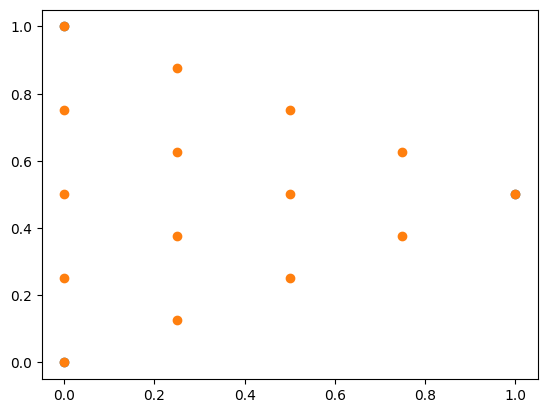

In [32]:
fig, ax = plt.subplots()
ax.scatter(tri_pts[:,0], tri_pts[:,1])
ax.scatter(pts[:,0], pts[:,1])


In [128]:
A = np.random.randint(1, 9, (4, 3)) #size: (2, 4, 3)

In [131]:
A, np.roll(A, -1, axis=0)

(array([[4, 3, 4],
        [4, 1, 5],
        [6, 6, 6],
        [5, 3, 5]]),
 array([[4, 1, 5],
        [6, 6, 6],
        [5, 3, 5],
        [4, 3, 4]]))

In [115]:
A = np.roll(Xf[0], -1, axis=0) # (4, 3)
B = np.repeat(Xw_face_centers[0].reshape(1,3), 4, axis=0) # (4, 3)

triangles = np.stack([Xf[0], A, B], axis=1) # (3, 3, 4)
triangles

array([[[-2.49837565e-01, -4.00061176e-01,  8.87447183e-01],
        [ 2.49892703e-01, -3.99913459e-01,  8.87269846e-01],
        [ 5.11704533e-05, -1.99976136e-01,  8.87385730e-01]],

       [[ 2.49892703e-01, -3.99913459e-01,  8.87269846e-01],
        [ 2.49975063e-01,  1.46210794e-04,  8.87293986e-01],
        [ 5.11704533e-05, -1.99976136e-01,  8.87385730e-01]],

       [[ 2.49975063e-01,  1.46210794e-04,  8.87293986e-01],
        [-2.49825519e-01, -7.61206901e-05,  8.87531904e-01],
        [ 5.11704533e-05, -1.99976136e-01,  8.87385730e-01]],

       [[-2.49825519e-01, -7.61206901e-05,  8.87531904e-01],
        [-2.49837565e-01, -4.00061176e-01,  8.87447183e-01],
        [ 5.11704533e-05, -1.99976136e-01,  8.87385730e-01]]])

In [ ]:
for i in range(1000):
    cloth.simulate(u = u, control = inds_ctr)
u = cloth.positions[inds_ctr]; 
for i in range(tf):
    u[:,1] += 0.0035*np.sin(freq*t[i])
    cloth.simulate(u = u, control = inds_ctr)
inds_ctr = [0]
u = cloth.positions[inds_ctr]; 
for i in range(1000):
    cloth.simulate(u = u, control = inds_ctr)

In [ ]:
print('Average iterations',cloth.total_iters/(len(cloth.history_pos)-1))

In [ ]:
cloth.makeMovie(speed = 6, repeat = True, smooth = 2)

In [ ]:
inds_ctr